# Project Overview

This project builds a short-term electricity load forecasting model using AESO data. The goal is to predict Alberta’s hourly demand and understand key drivers such as time-of-day and seasonality.

**Data Description**

The dataset contains hourly Alberta Internal Load (AIL), pool price, and rolling average price from April 2024 to April 2026.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import scipy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/Private projects/AESO Data/HistoricalPoolPriceReportServlet_04-30-2024_to_04-15-2026 - .csv", header=3)
df_badheader = df_raw.copy()
df_badheader.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Date (HE),Price ($),30Ravg ($),AIL Demand (MW)
1,04/30/2024 01,64.5,68.48,8962
2,04/30/2024 02,101.8,68.56,8893
3,04/30/2024 03,33.68,68.54,8879
4,04/30/2024 04,33.63,68.52,8905


In [ ]:
# fix the column header
df_fixed = df_badheader.copy()
df_fixed.columns = df_fixed.iloc[0]
df_fixed = df_fixed.iloc[1:].reset_index(drop=True)
df_fixed.head()

,Date (HE),Price ($),30Ravg ($),AIL Demand (MW)
0,04/30/2024 01,64.5,68.48,8962
1,04/30/2024 02,101.8,68.56,8893
2,04/30/2024 03,33.68,68.54,8879
3,04/30/2024 04,33.63,68.52,8905
4,04/30/2024 05,33.36,68.5,8944


In [ ]:
# rename for simplicity
df_fixed = df_fixed.rename(columns={
    "Date (HE)": "date_he",
    "Price ($)": "pool_price",
    "30Ravg ($)": "price_30d_avg",
    "AIL Demand (MW)": "load"
})

df_fixed.head()

,date_he,pool_price,price_30d_avg,load
0,04/30/2024 01,64.5,68.48,8962
1,04/30/2024 02,101.8,68.56,8893
2,04/30/2024 03,33.68,68.54,8879
3,04/30/2024 04,33.63,68.52,8905
4,04/30/2024 05,33.36,68.5,8944


In [ ]:
# inspect data and check for missing values
df_fixed.info()
df_fixed.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17184 entries, 0 to 17183
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date_he        17184 non-null  object
 1   pool_price     17184 non-null  object
 2   price_30d_avg  17184 non-null  object
 3   load           17184 non-null  object
dtypes: object(4)
memory usage: 537.1+ KB


,0
0,
date_he,0
pool_price,0
price_30d_avg,0
load,0


In [ ]:
# split date and hour
df_fixed[['date', 'he_raw']] = df_fixed['date_he'].str.split(' ', expand=True)
df_fixed['he_raw'].unique()

array(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',
       '23', '24', '02*'], dtype=object)

In [ ]:
# make a fresh copy
df_model = df_fixed.copy()

# 1) extract numeric HE and preserve DST repeat flag
df_model['he'] = df_model['he_raw'].str.extract(r'(\d+)').astype(int)
df_model['is_dst_repeat'] = df_model['he_raw'].str.contains(r'\*', na=False)

In [ ]:
# 2) convert date column
df_model['date'] = pd.to_datetime(df_model['date'])

# 3) convert numeric columns
df_model['load'] = pd.to_numeric(df_model['load'], errors='coerce')
df_model['pool_price'] = pd.to_numeric(df_model['pool_price'], errors='coerce')
df_model['price_30d_avg'] = pd.to_numeric(df_model['price_30d_avg'], errors='coerce')

In [ ]:
# 4) drop rows missing key modeling values
df_model = df_model.dropna(subset=['date', 'he', 'load'])

# 5) sort in true chronological order
# for repeated DST hour: regular HE 02 comes before HE 02*
df_model = df_model.sort_values(['date', 'he', 'is_dst_repeat']).reset_index(drop=True)

# 6) build a continuous hourly modeling timestamp
# starts at the first observed date, hour beginning of HE 01 = 00:00
start_ts = df_model.loc[0, 'date'] + pd.Timedelta(hours=df_model.loc[0, 'he'] - 1)
df_model['timestamp'] = start_ts + pd.to_timedelta(df_model.index, unit='h')

# 7) set modeling index
df_model = df_model.set_index('timestamp').sort_index()

In [ ]:
# sanity checks
print("Duplicate timestamps:", df_model.index.duplicated().sum())
expected_range = pd.date_range(df_model.index.min(), df_model.index.max(), freq='h')

print("Missing hours:", len(expected_range.difference(df_model.index)))

df_model.head()

Duplicate timestamps: 0
Missing hours: 0


,date_he,pool_price,price_30d_avg,load,date,he_raw,he,is_dst_repeat
timestamp,,,,,,,,
2024-04-30 00:00:00,04/30/2024 01,64.50,68.48,8962,2024-04-30,01,1,False
2024-04-30 01:00:00,04/30/2024 02,101.80,68.56,8893,2024-04-30,02,2,False
2024-04-30 02:00:00,04/30/2024 03,33.68,68.54,8879,2024-04-30,03,3,False
2024-04-30 03:00:00,04/30/2024 04,33.63,68.52,8905,2024-04-30,04,4,False
2024-04-30 04:00:00,04/30/2024 05,33.36,68.50,8944,2024-04-30,05,5,False


# Observations from data cleaning and preprocessing
- the data is highly time sensitive, since everything is hourly, the patterns are very precise and even a i hour misalignment matters
- DST is a critical issue, the clock is not always continous but the grid operates continously, where certain hours repeat (e.g., HE 02 and HE 02*) to  preserve the structure i created a continuous hourly index to ensure no duplicate or missing timestamps, making the dataset suitable for time-series modeling  

In [ ]:
# create time features
df_model['hour'] = df_model.index.hour
df_model['dayofweek'] = df_model.index.dayofweek
df_model['month'] = df_model.index.month
df_model['day'] = df_model.index.day
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)

In [ ]:
# create lag features
df_model['lag_1'] = df_model['load'].shift(1)
df_model['lag_24'] = df_model['load'].shift(24)
df_model['lag_168'] = df_model['load'].shift(168)   # same hour last week

# create rolling features
df_model['rolling_24'] = df_model['load'].rolling(24).mean()
df_model['rolling_168'] = df_model['load'].rolling(168).mean()

In [ ]:
# convert price columns to numeric
df_model['pool_price'] = pd.to_numeric(df_model['pool_price'], errors='coerce')
df_model['price_30d_avg'] = pd.to_numeric(df_model['price_30d_avg'], errors='coerce')

In [ ]:
# drop columns not needed for modeling
df_model = df_model.drop(columns=['date_he', 'date', 'he_raw'], errors='ignore')

# drop missing rows caused by lags/rolling
df_model = df_model.dropna()

In [ ]:
# define features and targets
X = df_model.drop(columns=['load'])
y = df_model['load']

In [ ]:
# check resuluts
print(X.dtypes)
print(X.head())
print(y.head())

0
pool_price       float64
price_30d_avg    float64
he                 int64
is_dst_repeat       bool
hour               int32
dayofweek          int32
month              int32
day                int32
is_weekend         int64
lag_1            float64
lag_24           float64
lag_168          float64
rolling_24       float64
rolling_168      float64
dtype: object
0                    pool_price  price_30d_avg  he  is_dst_repeat  hour  \
timestamp                                                                 
2024-05-07 00:00:00       16.26          47.73   1          False     0   
2024-05-07 01:00:00       17.04          47.69   2          False     1   
2024-05-07 02:00:00       15.40          47.63   3          False     2   
2024-05-07 03:00:00       14.30          47.60   4          False     3   
2024-05-07 04:00:00       14.00          47.54   5          False     4   

0                    dayofweek  month  day  is_weekend   lag_1  lag_24  \
timestamp                         

In [ ]:
# train/test split
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
# initialize baseline model
lr = LinearRegression()

# train model
lr.fit(X_train, y_train)

# make predictions
y_pred_lr = lr.predict(X_test)

In [ ]:
# evaluate the linear regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"MAE: {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²: {r2_lr:.2f}")

Linear Regression Performance:
MAE: 99.77
RMSE: 127.61
R²: 0.96


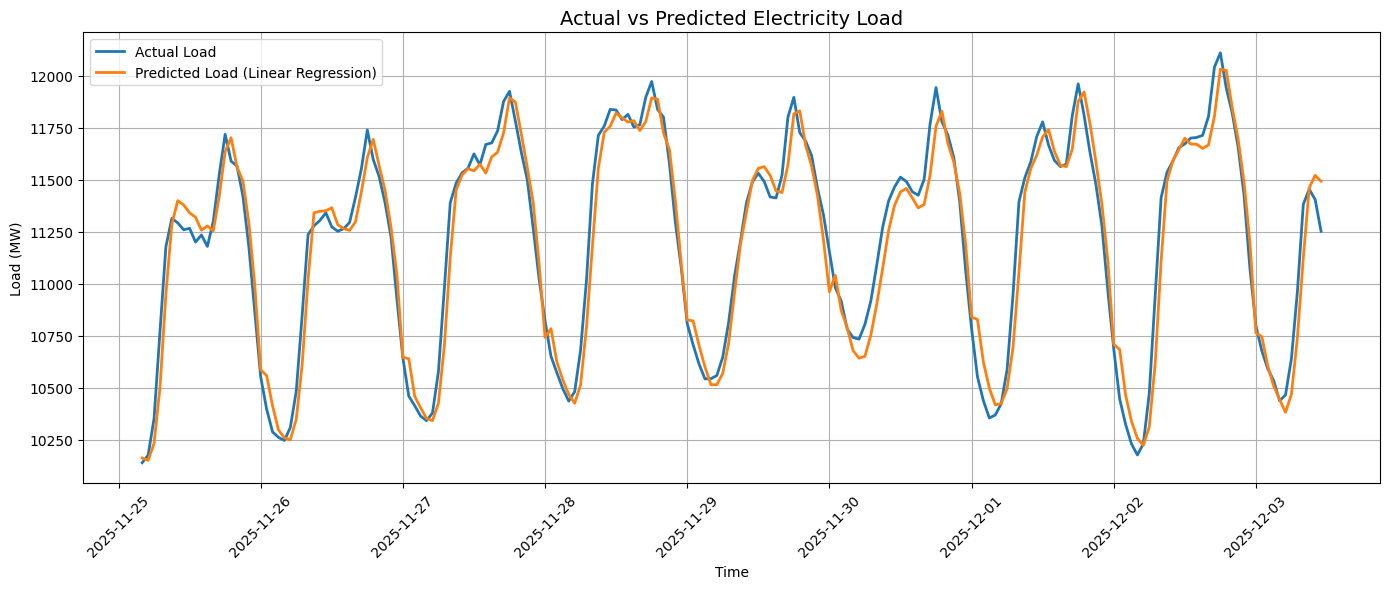

In [ ]:
# create baseline model visual
plt.figure(figsize=(14,6))

plt.plot(y_test.index[:200], y_test.values[:200], label='Actual Load', linewidth=2)
plt.plot(y_test.index[:200], y_pred_lr[:200], label='Predicted Load (Linear Regression)', linewidth=2)

plt.title("Actual vs Predicted Electricity Load", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Observations from baseline model**
- R² = 0.96 ; this is a very strong fit the medel explains 96% of hte variation in the load
- MAE is ~ 100MW; on average the forcast is off by 100MW
- the RMSE is ~ 128MW; it is slightly higher than MAE the gap between MAE and RMSE indicates occasional spikes or dips are not captured well, likely driven by external factors such as weather that were not included in the model
- Seasonality is captured well

**Insights from baseline model**
- Load is highly predictable, the structure of demand is very stable and repeatable
- Load forecasting is more about good feature engineering than complex models
- Load is highly autocorrelated meaning electric demand strongly depends on its own past values i.e. lag features are extemely powerful
- the model is strong but may struggle with sudden changes, so while it performs well in normal conditions it may miss heat waves and cold snaps  




In [ ]:
# train XGBoost model
model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# predict
y_pred_xgb = model.predict(X_test)

In [ ]:
# evaluate the xgboost model
mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
r2_xgb = r2_score(y_test, y_pred)

print("XGBoost Performance:")
print(f"MAE:{mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R²: {r2_xgb:.2f}")

XGBoost Performance:
MAE:64.55
RMSE: 92.71
R²: 0.98


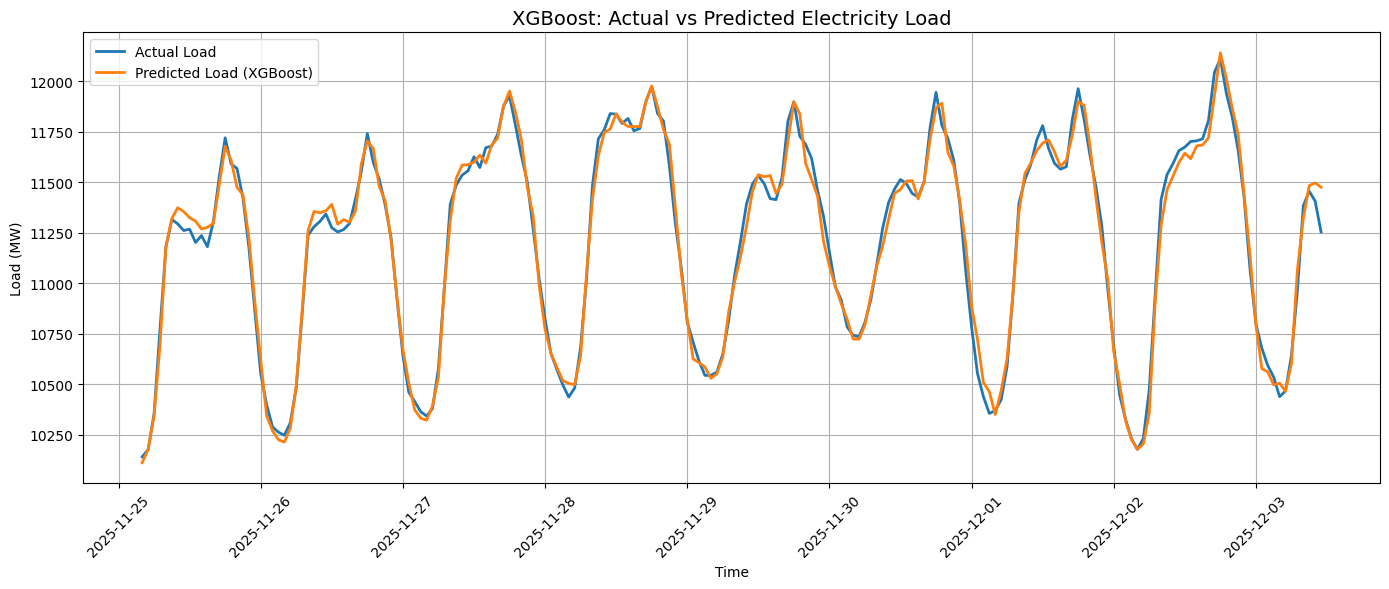

In [ ]:
# plot results
plt.figure(figsize=(14,6))

plt.plot(y_test.index[:200], y_test.values[:200],label='Actual Load', linewidth=2)
plt.plot(y_test.index[:200], y_pred_xgb[:200], label='Predicted Load (XGBoost)', linewidth=2)

plt.title("XGBoost: Actual vs Predicted Electricity Load", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Obervations from the XGBoost model**
- R² = 0.98; even higher predictive power, the model explains 98% of load variation
- MAE is ~ 65MW a significant error reduction from the baseline model
- RMSE also dropped a lot from 127 in the linear model to 92 in the non-linear model

**Insights from the XGBoost model**
- The model captures almost all the structure in demand with extremly tight forecasting
- THis model is much better at handling spikes and extremes
- The improvement likely comes from its better handling of non linear relationships but the model is still heavily driven by lag features  

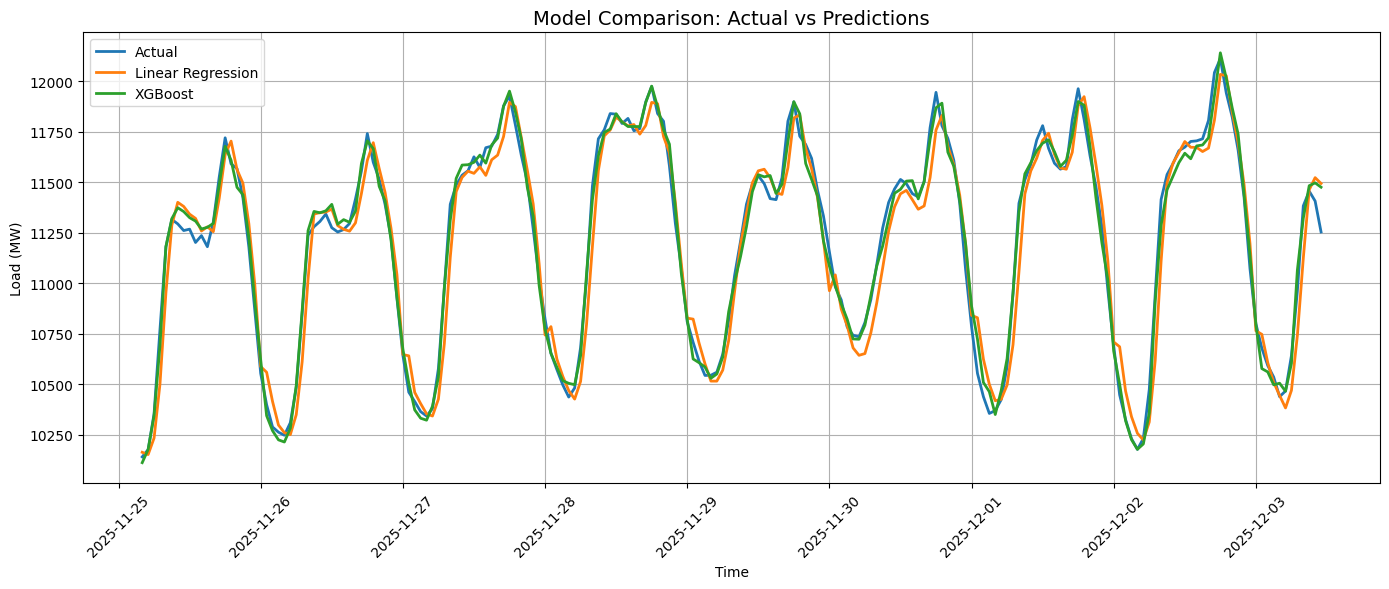

In [ ]:
# plot the two models together
plt.figure(figsize=(14,6))

plt.plot(y_test.index[:200], y_test.values[:200], label='Actual', linewidth=2)
plt.plot(y_test.index[:200], y_pred_lr[:200], label='Linear Regression', linewidth=2)
plt.plot(y_test.index[:200], y_pred_xgb[:200], label='XGBoost', linewidth=2)

plt.title("Model Comparison: Actual vs Predictions", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


| Metric  | Linear   |XGBoost  |Improvement |
|---------|--------- |-------- |---------|
| MAE     | ~100     |~65      | 35% better   |
| RMSE    | ~128     |~93      | 27% better   |
| R²      | 0.96     |0.98     | modest gain   |

**Insights from the comparison**
- Improvement is meaning ful but not huge
- XGBoost mostly improves edge cases, the forcast of the peaks and valleys or sudden changes  
- There are diminishing returns from model complexitiy. Ultimately the lags and time features matter more tha nthe model complexity

#**Conclusion**
- Both models perform well, lag features explain most of the variation
- XGBoost adds value by capturing non lineralty and improving peak accuracy

In [ ]:
results_df = pd.DataFrame({
    "timestamp": y_test.index,
    "actual_load": y_test.values,
    "pred_lr": y_pred_lr,
    "pred_xgb": y_pred_xgb
})

results_df = results_df.reset_index(drop=True)
results_df.to_csv("model_outputs.csv", index=False)

In [ ]:
metrics_df = pd.DataFrame({
    "model": ["Linear Regression", "XGBoost"],
    "MAE": [mae_lr, mae_xgb],
    "RMSE": [rmse_lr, rmse_xgb],
    "R2": [r2_lr, r2_xgb]
})

metrics_df.to_csv("metrics.csv", index=False)